In [35]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

In [34]:
df = pd.read_csv("/Users/diyakadakia/Desktop/ml2-final-project/data/311-service-requests-from-2010-to-present.csv", nrows=1000000)

/var/folders/hx/fk68477s3096pwy_7thf3w2c0000gn/T/ipykernel_33216/3214094747.py:1: DtypeWarning: Columns (31,32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/diyakadakia/Desktop/ml2-final-project/data/311-service-requests-from-2010-to-present.csv", nrows=1000000)


In [17]:
pd.set_option('display.max_columns', None)
df.head()


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,Intersection Street 1,Intersection Street 2,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,Resolution Action Updated Date,Community Board,BBL,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,WEST 29 STREET,5 AVENUE,BROADWAY,NaN,NaN,BLOCKFACE,NEW YORK,NaN,NaN,Open,NaN,The Department of Transportation referred this...,2019-12-01T02:04:01.000,05 MANHATTAN,NaN,MANHATTAN,987653.0,210944.0,UNKNOWN,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,AVENUE U,WEST 7 STREET,WEST 6 STREET,WEST 7 STREET,WEST 6 STREET,NaN,BROOKLYN,AVENUE U,NaN,In Progress,NaN,NaN,NaN,15 BROOKLYN,3.071200e+09,BROOKLYN,990437.0,156589.0,PHONE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,SCHENCK AVENUE,LINDEN BOULEVARD,STANLEY AVENUE,LINDEN BOULEVARD,STANLEY AVENUE,NaN,BROOKLYN,SCHENCK AVENUE,NaN,In Progress,NaN,NaN,NaN,05 BROOKLYN,3.043550e+09,BROOKLYN,1016570.0,179974.0,ONLINE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN
3,45052046,2019-12-01T01:58:23.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11358.0,42-41 159 STREET,159 STREET,SANFORD AVENUE,43 AVENUE,SANFORD AVENUE,43 AVENUE,NaN,FLUSHING,159 STREET,NaN,In Progress,NaN,NaN,NaN,07 QUEENS,4.053900e+09,QUEENS,1037757.0,216222.0,MOBILE,Unspecified,QUEENS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.759994,-73.806856,"{'longitude': '-73.80685560533585', 'latitude'...",NaN,NaN,NaN,NaN,NaN
4,45054999,2019-12-01T01:58:07.000,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11426.0,88-49 237 STREET,237 STREET,88 AVENUE,89 AVENUE,88 AVENUE,89 AVENUE,NaN,BELLEROSE,237 STREET,NaN,In Progress,NaN,NaN,NaN,13 QUEENS,4.079760e+09,QUEENS,1059083.0,205168.0,ONLINE,Unspecified,QUEENS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.729499,-73.729998,"{'longitude': '-73.72999847973517', 'latitude'...",NaN,NaN,NaN,NaN,NaN


In [ ]:
# Basic Information 
print(df.dtypes)
print("\nMissing values (%):")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(20))

Unique Key                          int64
Created Date                       object
Closed Date                        object
Agency                             object
Agency Name                        object
Complaint Type                     object
Descriptor                         object
Location Type                      object
Incident Zip                      float64
Incident Address                   object
Street Name                        object
Cross Street 1                     object
Cross Street 2                     object
Intersection Street 1              object
Intersection Street 2              object
Address Type                       object
City                               object
Landmark                           object
Facility Type                      object
Status                             object
Due Date                          float64
Resolution Description             object
Resolution Action Updated Date     object
Community Board                   

In [20]:
# Drop columns with high null values
drop_cols = [
    'Due Date', 'Bridge Highway Name', 'Vehicle Type', 'Taxi Company Borough',
    'Bridge Highway Segment', 'Road Ramp', 'Bridge Highway Direction',
    'Facility Type', 'Taxi Pick Up Location']

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,Intersection Street 1,Intersection Street 2,Address Type,City,Landmark,Status,Resolution Description,Resolution Action Updated Date,Community Board,BBL,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Latitude,Longitude,Location,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,45050101,2019-12-01T02:04:01.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,10001.0,WEST 29 STREET,WEST 29 STREET,5 AVENUE,BROADWAY,NaN,NaN,BLOCKFACE,NEW YORK,NaN,Open,The Department of Transportation referred this...,2019-12-01T02:04:01.000,05 MANHATTAN,NaN,MANHATTAN,987653.0,210944.0,UNKNOWN,Unspecified,MANHATTAN,40.745668,-73.987719,"{'longitude': '-73.9877188309367', 'latitude':...",NaN,NaN,NaN,NaN,NaN
1,45054936,2019-12-01T01:59:41.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11223.0,178 AVENUE U,AVENUE U,WEST 7 STREET,WEST 6 STREET,WEST 7 STREET,WEST 6 STREET,NaN,BROOKLYN,AVENUE U,In Progress,NaN,NaN,15 BROOKLYN,3.071200e+09,BROOKLYN,990437.0,156589.0,PHONE,Unspecified,BROOKLYN,40.596475,-73.977721,"{'longitude': '-73.97772147626671', 'latitude'...",NaN,NaN,NaN,NaN,NaN
2,45049329,2019-12-01T01:59:08.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11207.0,807 SCHENCK AVENUE,SCHENCK AVENUE,LINDEN BOULEVARD,STANLEY AVENUE,LINDEN BOULEVARD,STANLEY AVENUE,NaN,BROOKLYN,SCHENCK AVENUE,In Progress,NaN,NaN,05 BROOKLYN,3.043550e+09,BROOKLYN,1016570.0,179974.0,ONLINE,Unspecified,BROOKLYN,40.660605,-73.883508,"{'longitude': '-73.8835082736363', 'latitude':...",NaN,NaN,NaN,NaN,NaN
3,45052046,2019-12-01T01:58:23.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11358.0,42-41 159 STREET,159 STREET,SANFORD AVENUE,43 AVENUE,SANFORD AVENUE,43 AVENUE,NaN,FLUSHING,159 STREET,In Progress,NaN,NaN,07 QUEENS,4.053900e+09,QUEENS,1037757.0,216222.0,MOBILE,Unspecified,QUEENS,40.759994,-73.806856,"{'longitude': '-73.80685560533585', 'latitude'...",NaN,NaN,NaN,NaN,NaN
4,45054999,2019-12-01T01:58:07.000,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11426.0,88-49 237 STREET,237 STREET,88 AVENUE,89 AVENUE,88 AVENUE,89 AVENUE,NaN,BELLEROSE,237 STREET,In Progress,NaN,NaN,13 QUEENS,4.079760e+09,QUEENS,1059083.0,205168.0,ONLINE,Unspecified,QUEENS,40.729499,-73.729998,"{'longitude': '-73.72999847973517', 'latitude'...",NaN,NaN,NaN,NaN,NaN


In [ ]:
# Dates and Resolution Times
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date']  = pd.to_datetime(df['Closed Date'],  errors='coerce')
df['resolution_hours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600

In [ ]:
# Only keep closed requests with valid positive resolution time
df_closed = df.dropna(subset=['resolution_hours'])
df_closed = df_closed[df_closed['resolution_hours'] > 0]
cap = df_closed['resolution_hours'].quantile(0.99)
df_closed = df_closed[df_closed['resolution_hours'] <= cap]

print(f"\nClosed requests: {len(df_closed):,} / {len(df):,} ({len(df_closed)/len(df)*100:.1f}%)")
print(f"Resolution time — mean: {df_closed['resolution_hours'].mean():.1f}h  "
      f"median: {df_closed['resolution_hours'].median():.1f}h  "
      f"max (99th pct): {cap:.1f}h")


Closed requests: 848,152 / 1,000,000 (84.8%)
Resolution time — mean: 80.9h  median: 8.4h  max (99th pct): 1254.2h


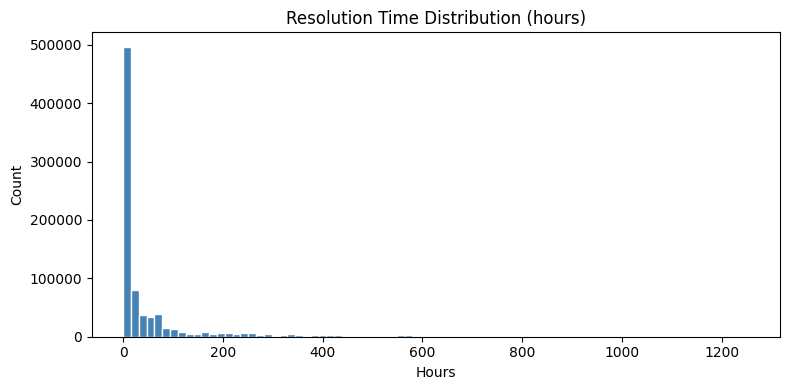

In [ ]:
# Resolution Time Distribution
plt.figure(figsize=(8, 4))
plt.hist(df_closed['resolution_hours'], bins=80, color='steelblue', edgecolor='white')
plt.title('Resolution Time Distribution (hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

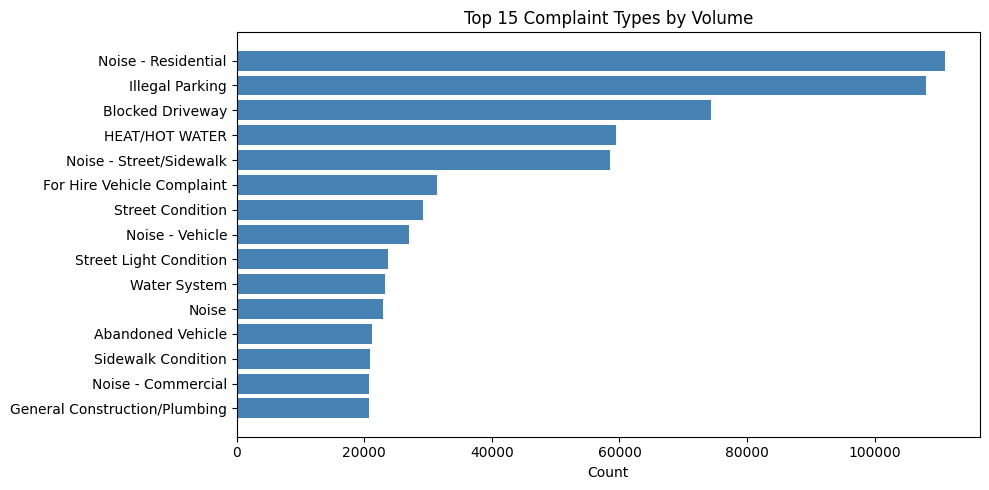

In [ ]:
# Top Complaint Types 
top_complaints = df['Complaint Type'].value_counts().head(15)
plt.figure(figsize=(10, 5))
plt.barh(top_complaints.index[::-1], top_complaints.values[::-1], color='steelblue')
plt.title('Top 15 Complaint Types by Volume')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

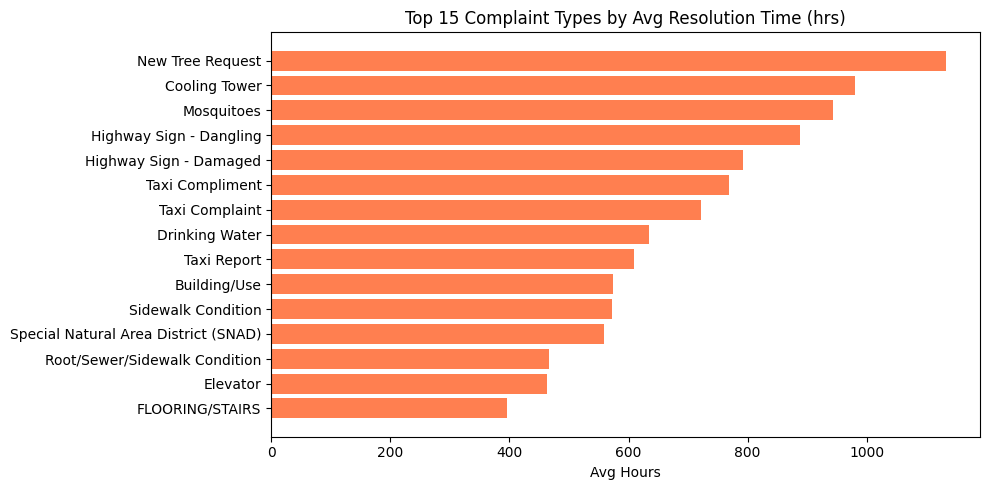

In [ ]:
# Avg resolution time by complaint type
avg_res = (df_closed.groupby('Complaint Type')['resolution_hours']
           .mean().sort_values(ascending=False).head(15))
plt.figure(figsize=(10, 5))
plt.barh(avg_res.index[::-1], avg_res.values[::-1], color='coral')
plt.title('Top 15 Complaint Types by Avg Resolution Time (hrs)')
plt.xlabel('Avg Hours')
plt.tight_layout()
plt.show()

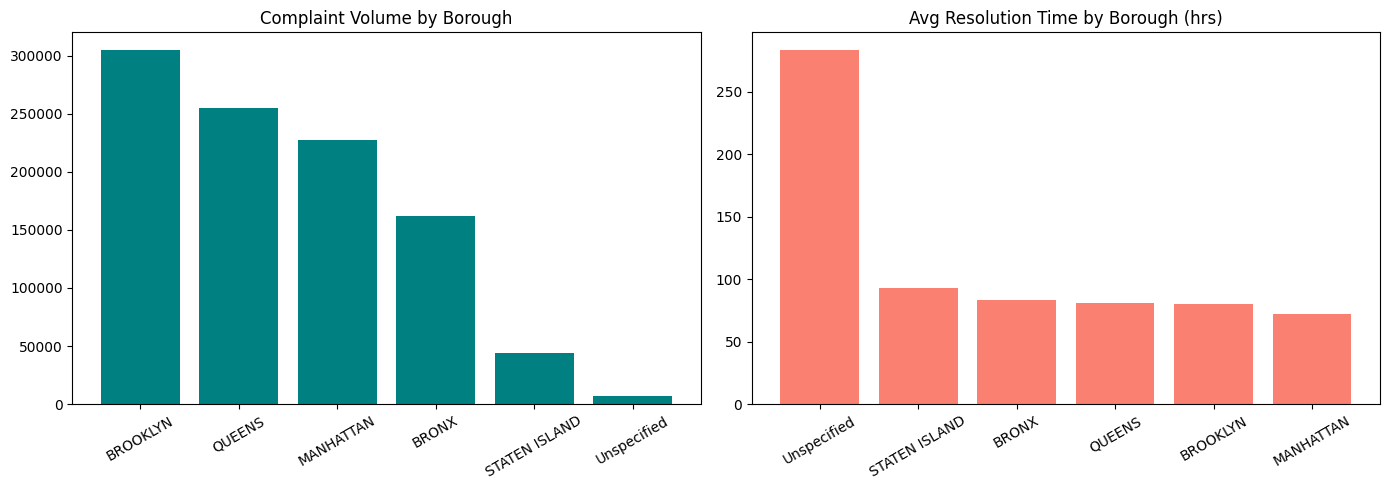

In [ ]:
# Borough 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

borough_vol = df['Borough'].value_counts()
axes[0].bar(borough_vol.index, borough_vol.values, color='teal')
axes[0].set_title('Complaint Volume by Borough')
axes[0].tick_params(axis='x', rotation=30)

borough_res = df_closed.groupby('Borough')['resolution_hours'].mean().sort_values(ascending=False)
axes[1].bar(borough_res.index, borough_res.values, color='salmon')
axes[1].set_title('Avg Resolution Time by Borough (hrs)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

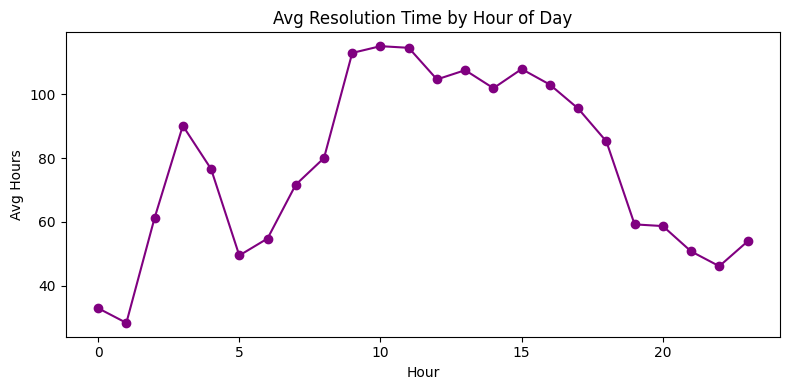

In [ ]:
# Time of Day
df_closed['hour']      = df_closed['Created Date'].dt.hour

plt.figure(figsize=(8, 4))
plt.plot(df_closed.groupby('hour')['resolution_hours'].mean(), marker='o', color='purple')
plt.title('Avg Resolution Time by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Hours')
plt.tight_layout()
plt.show() 